In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models, expected_returns, plotting


In [14]:
# 1. Load data and calculate daily returns
prices_df = pd.read_csv('../data/processed/cleaned_prices.csv', index_col='Date', parse_dates=True)
# Ensure data is sorted by date and handle any missing values
prices_df = prices_df.sort_index().ffill().dropna()


In [15]:
# 2. Prepare Expected Returns (mu)
# We use mean_historical_return which annualizes the data
mu = expected_returns.mean_historical_return(prices_df)

# OVERWRITE TSLA with your forecast from Task 3
mu['TSLA'] = 0.0011 # Forecasted 0.11% annualized return

# 3. Prepare Covariance Matrix (S)
S = risk_models.sample_cov(prices_df)

print("Annualized Expected Returns:\n", mu)

Annualized Expected Returns:
 BND     0.019177
SPY     0.135411
TSLA    0.001100
dtype: float64


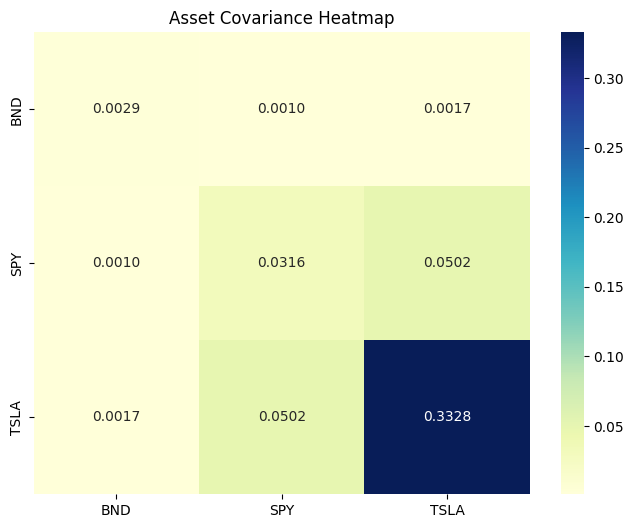

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(S, annot=True, cmap='YlGnBu', fmt=".4f")
plt.title('Asset Covariance Heatmap')
plt.show()

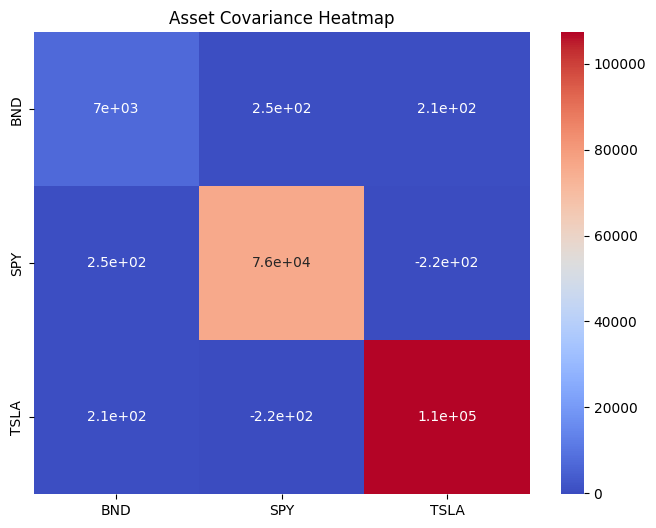

In [17]:
# Calculate the annualized sample covariance matrix
S = risk_models.sample_cov(returns_df)

# Visualize the Covariance Matrix (Deliverable)
plt.figure(figsize=(8, 6))
sns.heatmap(S, annot=True, cmap='coolwarm')
plt.title('Asset Covariance Heatmap')
plt.show()

In [18]:
# 1. Max Sharpe Ratio Portfolio
ef = EfficientFrontier(mu, S, solver="SCS")
weights_max_sharpe = ef.max_sharpe()
cleaned_weights = ef.clean_weights()
perf_max_sharpe = ef.portfolio_performance(verbose=True)

Expected annual return: 6.5%
Annual volatility: 12121.9%
Sharpe Ratio: 0.00


In [19]:
# 2. Min Volatility Portfolio
ef_min = EfficientFrontier(mu, S, solver="SCS")
weights_min_vol = ef_min.min_volatility()
perf_min_vol = ef_min.portfolio_performance(verbose=True)

print("\nOptimal Weights (Max Sharpe):", cleaned_weights)

Expected annual return: 2.7%
Annual volatility: 7818.3%
Sharpe Ratio: 0.00

Optimal Weights (Max Sharpe): OrderedDict([('BND', 0.60022), ('SPY', 0.39786), ('TSLA', 0.00191)])


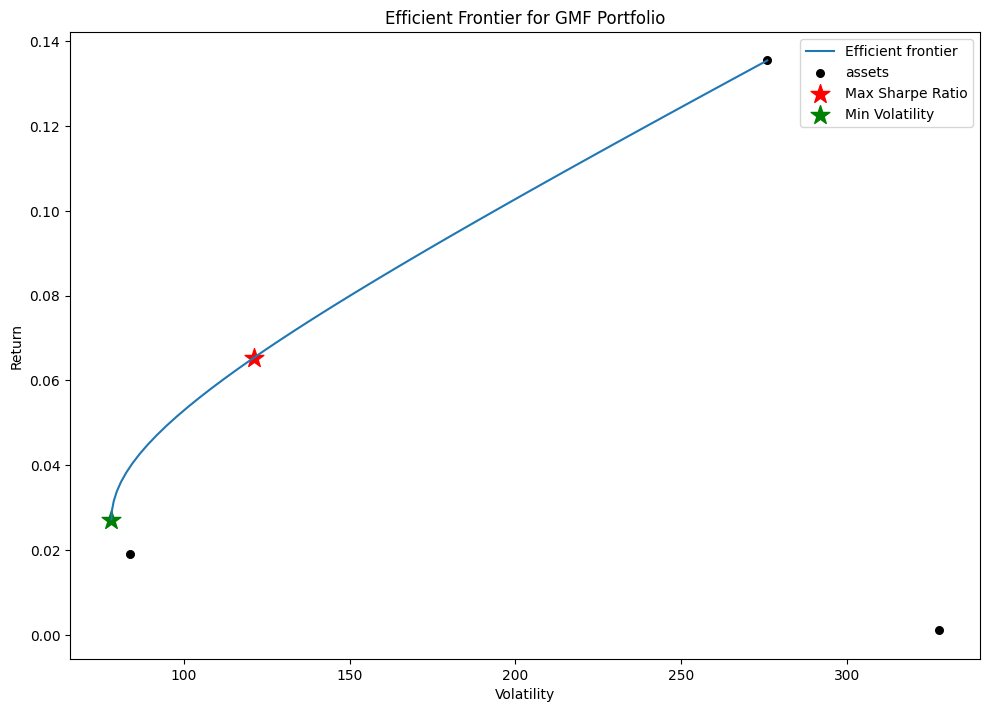

In [20]:
# Create a range of target returns between the min volatility and max available return
min_ret = perf_min_vol[0]
max_ret = mu.max()
# Define a range of 50 points to plot the line
target_returns = np.linspace(min_ret, max_ret, 50)

fig, ax = plt.subplots(figsize=(10, 7))
ef_plot = EfficientFrontier(mu, S, solver="SCS")

# FIX: Pass the manual range to ef_param_range to prevent CLARABEL from failing
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True, ef_param_range=target_returns)

# Mark the specific portfolios
ax.scatter(perf_max_sharpe[1], perf_max_sharpe[0], marker="*", s=200, c="red", label="Max Sharpe Ratio")
ax.scatter(perf_min_vol[1], perf_min_vol[0], marker="*", s=200, c="green", label="Min Volatility")

ax.set_title("Efficient Frontier for GMF Portfolio")
ax.legend()
plt.show()